# Taxonomy Analysis

Exploration des résultats taxonomy (majority vote Claude × DeepSeek × Mistral) :
évolution temporelle, types de tâches, entrées, domaines, sources de données.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

sys.path.insert(0, str(Path().resolve().parent))

In [2]:
DATA_DIR = Path("../data")

positives = pd.read_parquet(DATA_DIR / "taxonomy" / "merged.parquet")
anthology = pd.read_parquet(DATA_DIR / "raw" / "anthology_enriched.parquet")

common = positives.columns.intersection(anthology.columns).difference(["bibkey"])
positives = positives.merge(anthology.drop(columns=common), on="bibkey")

## Évolution temporelle du nombre de benchmarks

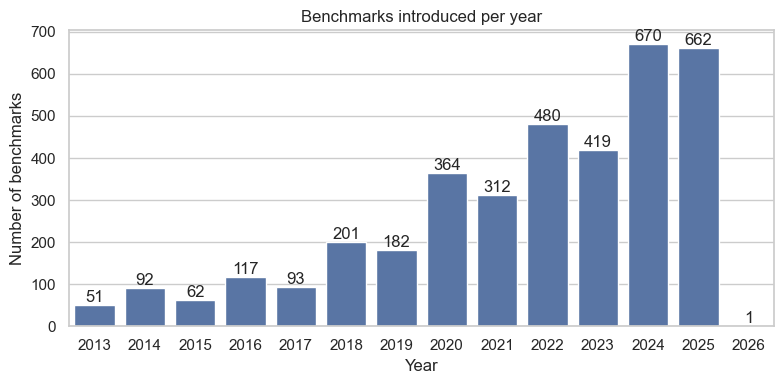

In [3]:
year_counts = positives.groupby("year")["majority_label"].count()

g = sns.barplot(x=year_counts.index, y=year_counts.values)
g.set(
    xlabel="Year", ylabel="Number of benchmarks", title="Benchmarks introduced per year"
)
g.bar_label(g.containers[0])
g.figure.set_size_inches(8, 4)
g.figure.tight_layout()

C:\Users\samma\AppData\Local\Temp\ipykernel_89608\2680240675.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")


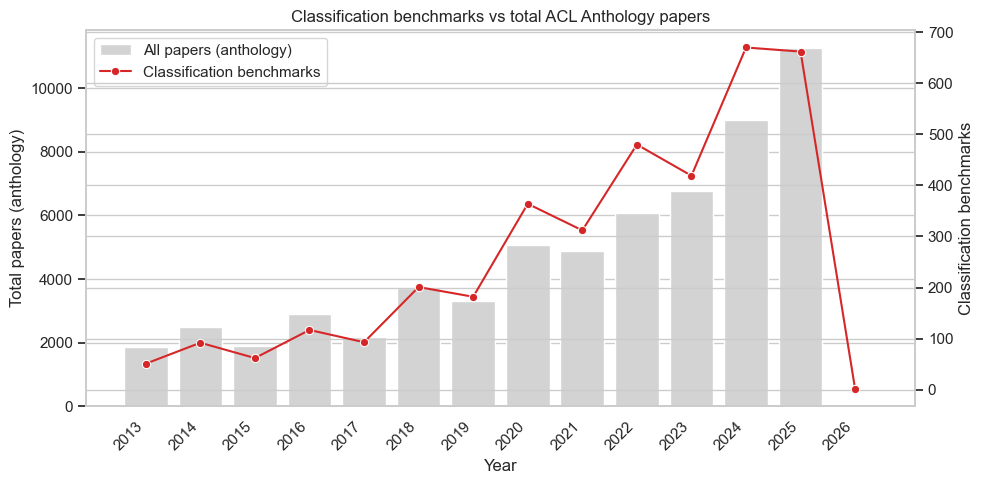

In [4]:
# Évolution comparée : benchmarks de classif vs total de papiers dans l'anthology
bench_per_year = positives.groupby("year").size().rename("benchmarks")
anthology_per_year = anthology.groupby("year").size().rename("anthology")

compared = pd.concat([anthology_per_year, bench_per_year], axis=1).fillna(0).astype(int)
compared["pct"] = (compared["benchmarks"] / compared["anthology"] * 100).round(2)

fig, ax1 = sns.mpl.pyplot.subplots(figsize=(10, 5))

sns.barplot(
    x=compared.index,
    y=compared["anthology"],
    color="lightgrey",
    label="All papers (anthology)",
    ax=ax1,
)
ax1.set_ylabel("Total papers (anthology)")
ax1.set_xlabel("Year")

ax2 = ax1.twinx()
sns.lineplot(
    x=range(len(compared)),
    y=compared["benchmarks"].values,
    color="tab:red",
    marker="o",
    label="Classification benchmarks",
    ax=ax2,
)
ax2.set_ylabel("Classification benchmarks")

# Combine legends
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")
ax2.get_legend().remove()

ax1.set_title("Classification benchmarks vs total ACL Anthology papers")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()

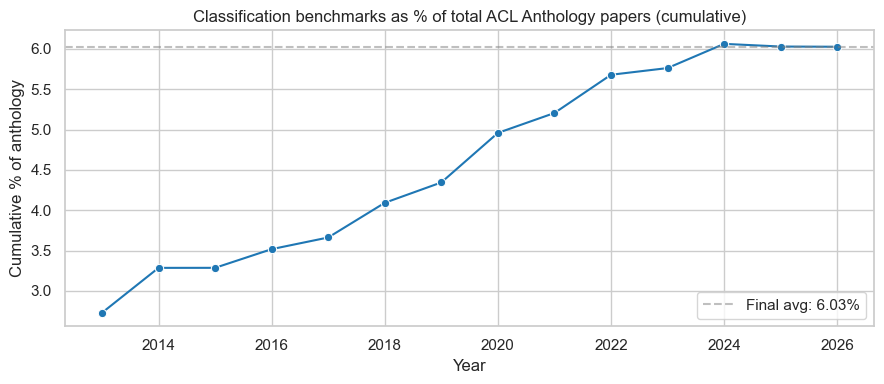

In [5]:
# Proportion de benchmarks de classif par rapport au total de l'anthology
# Courbe cumulative normalisée : si la ligne est plate, les benchmarks
# croissent au même rythme que le volume total de papiers.
cum_bench = compared["benchmarks"].cumsum()
cum_anthology = compared["anthology"].cumsum()
compared["bench_share_cum"] = cum_bench / cum_anthology * 100

g = sns.lineplot(
    x=compared.index, y=compared["bench_share_cum"], marker="o", color="tab:blue"
)
g.set(
    xlabel="Year",
    ylabel="Cumulative % of anthology",
    title="Classification benchmarks as % of total ACL Anthology papers (cumulative)",
)
g.axhline(
    compared["bench_share_cum"].iloc[-1],
    ls="--",
    color="grey",
    alpha=0.5,
    label=f"Final avg: {compared['bench_share_cum'].iloc[-1]:.2f}%",
)
g.legend()
g.figure.set_size_inches(9, 4)
g.figure.tight_layout()

## Task types

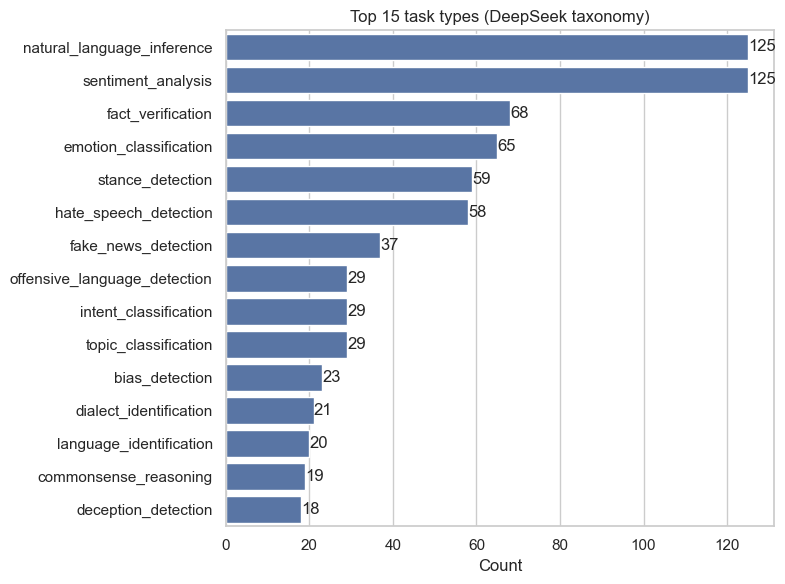

In [6]:
task_counts = positives["deepseek_task_type"].dropna().value_counts()

g = sns.barplot(y=task_counts.index[:15], x=task_counts.values[:15], orient="h")
g.set(xlabel="Count", ylabel="", title="Top 15 task types (DeepSeek taxonomy)")
g.bar_label(g.containers[0])
g.figure.set_size_inches(8, 6)
g.figure.tight_layout()

## Input type

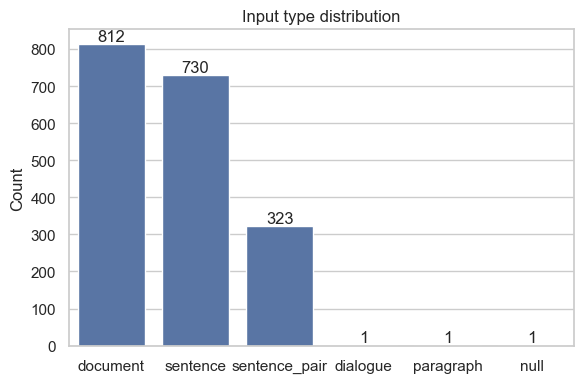

In [7]:
input_counts = positives["deepseek_input_type"].dropna().value_counts()

g = sns.barplot(x=input_counts.index, y=input_counts.values)
g.set(xlabel="", ylabel="Count", title="Input type distribution")
g.bar_label(g.containers[0])
g.figure.set_size_inches(6, 4)
g.figure.tight_layout()

## Label type (binary / multi-class / multi-label)

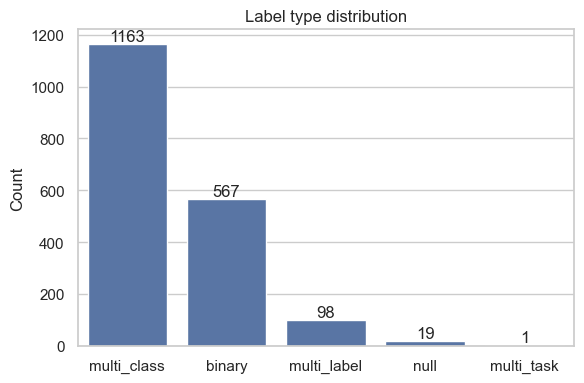

In [8]:
label_type_counts = positives["deepseek_label_type"].dropna().value_counts()

g = sns.barplot(x=label_type_counts.index, y=label_type_counts.values)
g.set(xlabel="", ylabel="Count", title="Label type distribution")
g.bar_label(g.containers[0])
g.figure.set_size_inches(6, 4)
g.figure.tight_layout()

## Domain

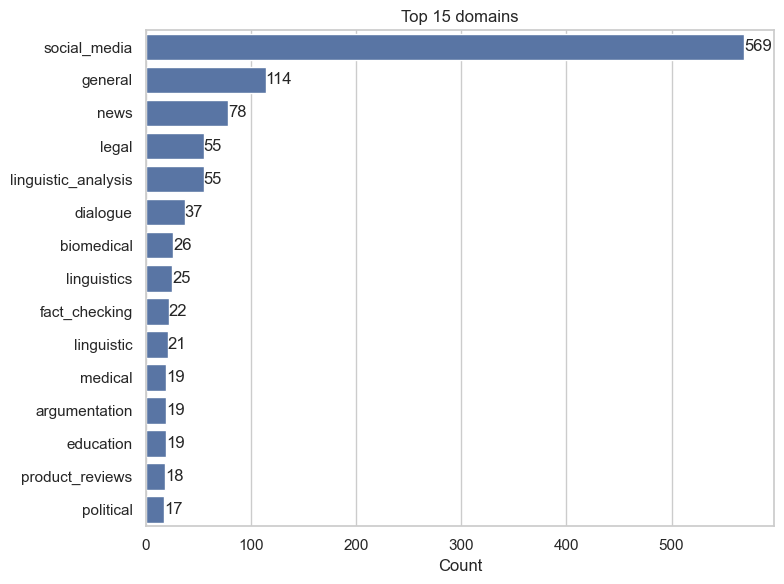

In [9]:
domain_counts = positives["deepseek_domain"].dropna().value_counts()

g = sns.barplot(y=domain_counts.index[:15], x=domain_counts.values[:15], orient="h")
g.set(xlabel="Count", ylabel="", title="Top 15 domains")
g.bar_label(g.containers[0])
g.figure.set_size_inches(8, 6)
g.figure.tight_layout()

## Languages

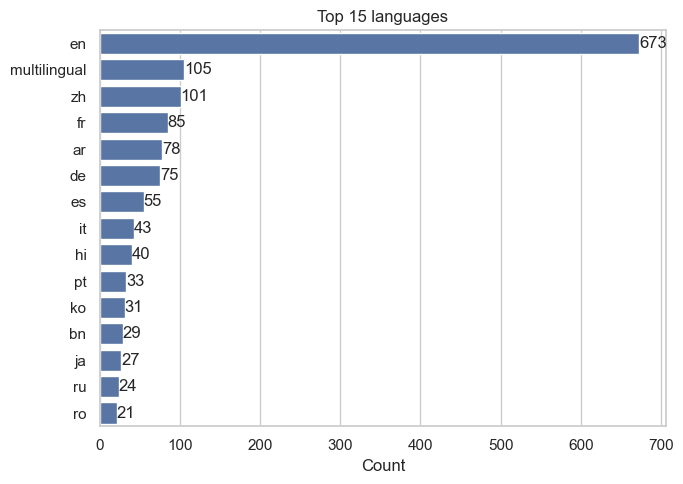

In [10]:
# Explode language lists into individual rows
langs = positives["deepseek_languages"].dropna().explode().value_counts()

g = sns.barplot(y=langs.index[:15], x=langs.values[:15], orient="h")
g.set(xlabel="Count", ylabel="", title="Top 15 languages")
g.bar_label(g.containers[0])
g.figure.set_size_inches(7, 5)
g.figure.tight_layout()

## Task type × Year heatmap

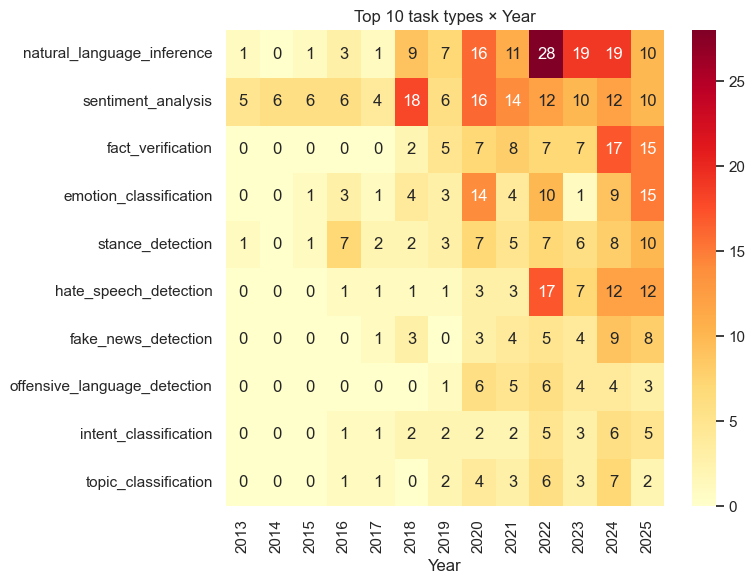

In [11]:
top_tasks = positives["deepseek_task_type"].dropna().value_counts().head(10).index
subset = positives[positives["deepseek_task_type"].isin(top_tasks)]

pivot = subset.groupby(["deepseek_task_type", "year"]).size().unstack(fill_value=0)
pivot = pivot.loc[top_tasks]  # keep order by frequency

g = sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd")
g.set(xlabel="Year", ylabel="", title="Top 10 task types × Year")
g.figure.set_size_inches(8, 6)
g.figure.tight_layout()

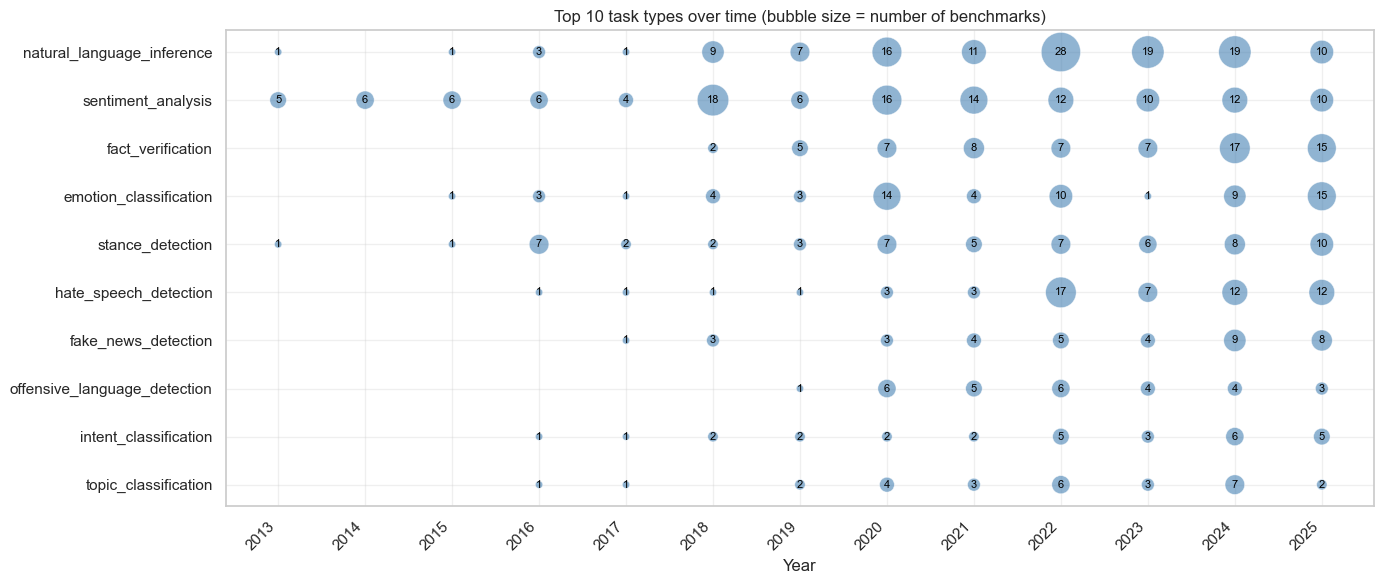

In [12]:
# Bubble chart: top task types × year (size = count)
top_n = 10
top_tasks = positives["deepseek_task_type"].dropna().value_counts().head(top_n).index
subset = positives[positives["deepseek_task_type"].isin(top_tasks)]

bubble = subset.groupby(["deepseek_task_type", "year"]).size().reset_index(name="count")

# Map task to y position (ordered by total frequency)
task_order = list(top_tasks)
bubble["y"] = bubble["deepseek_task_type"].map({t: i for i, t in enumerate(task_order)})

fig, ax = sns.mpl.pyplot.subplots(figsize=(14, 6))

# Scale bubble sizes
max_count = bubble["count"].max()
sizes = (bubble["count"] / max_count) * 800

ax.scatter(
    bubble["year"],
    bubble["y"],
    s=sizes,
    alpha=0.6,
    color="steelblue",
    edgecolors="white",
    linewidth=0.5,
)

# Annotate counts inside bubbles
for _, row in bubble.iterrows():
    ax.annotate(
        str(int(row["count"])),
        (row["year"], row["y"]),
        ha="center",
        va="center",
        fontsize=8,
        color="black",
    )

ax.set_yticks(range(len(task_order)))
ax.set_yticklabels(task_order)
ax.invert_yaxis()

years = sorted(bubble["year"].unique())
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, ha="right")

ax.set_xlabel("Year")
ax.set_ylabel("")
ax.set_title("Top 10 task types over time (bubble size = number of benchmarks)")
ax.grid(True, alpha=0.3)
fig.tight_layout()

## Domain × Input type

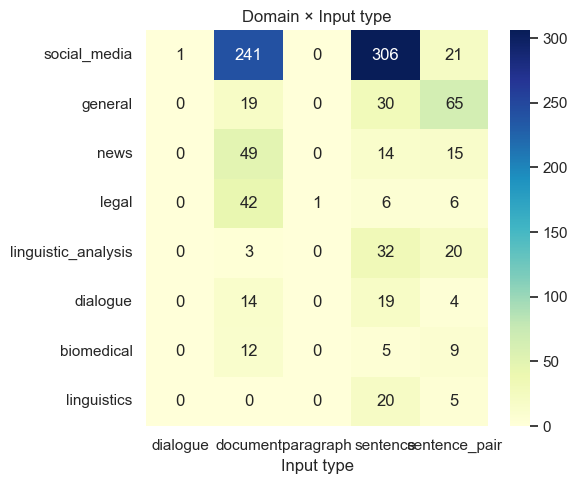

In [13]:
top_domains = positives["deepseek_domain"].dropna().value_counts().head(8).index
subset = positives[positives["deepseek_domain"].isin(top_domains)].dropna(
    subset=["deepseek_input_type"]
)

pivot = (
    subset.groupby(["deepseek_domain", "deepseek_input_type"])
    .size()
    .unstack(fill_value=0)
)
pivot = pivot.loc[top_domains]

g = sns.heatmap(pivot, annot=True, fmt="d", cmap="YlGnBu")
g.set(xlabel="Input type", ylabel="", title="Domain × Input type")
g.figure.set_size_inches(6, 5)
g.figure.tight_layout()